In [1]:
%pip install kagglehub numpy matplotlib pandas transformers scipy
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shuvoalok/dawn-dataset")

print("Path to dataset files:", path)


f:\repos\COMP9130proj\COMP9130_Final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\mwper\.cache\kagglehub\datasets\shuvoalok\dawn-dataset\versions\5


Found 1027 images under: C:\Users\mwper\.cache\kagglehub\datasets\shuvoalok\dawn-dataset\versions\5


Loading weights: 100%|██████████| 770/770 [00:00<00:00, 18791.14it/s]


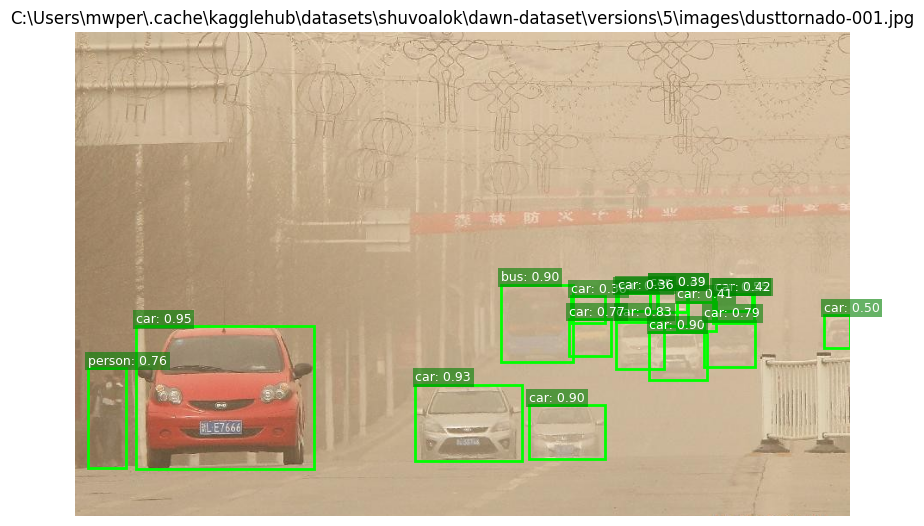

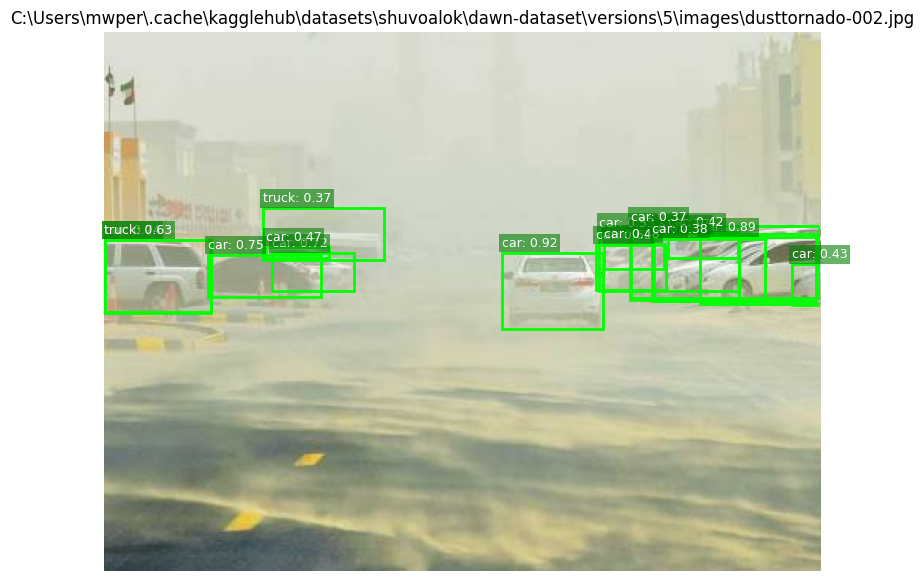

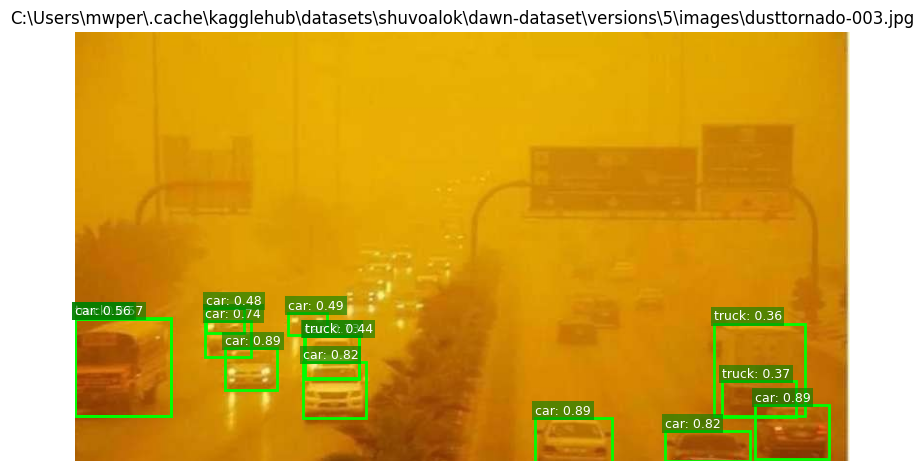

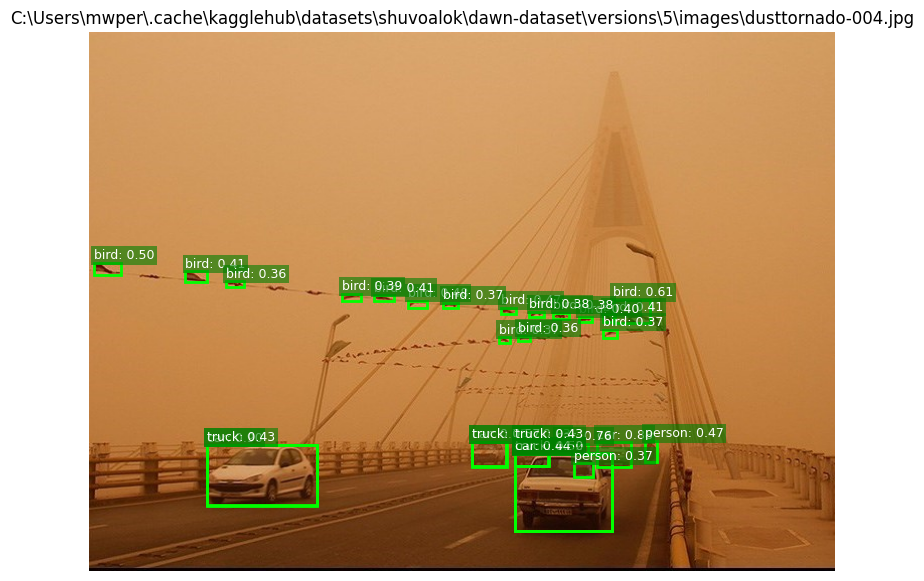

In [3]:
from pathlib import Path
from PIL import Image
import torch
from transformers import AutoImageProcessor, RTDetrV2ForObjectDetection

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1) Collect image files from the downloaded dataset
root = Path(path)
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = [p for p in root.rglob("*") if p.suffix.lower() in image_exts]

print(f"Found {len(image_paths)} images under: {root}")
if not image_paths:
    raise FileNotFoundError("No image files found in dataset path.")

# 2) Load RT-DETRv2 model + processor
model_id = "PekingU/rtdetr_v2_r50vd"
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(model_id)
model = RTDetrV2ForObjectDetection.from_pretrained(model_id).to(device).eval()

# 3) Run inference on a few sample images
sample_paths = image_paths[:4]  # change as needed

for img_path in sample_paths:
    image = Image.open(img_path).convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]], device=device)  # (h, w)
    results = processor.post_process_object_detection(
        outputs=outputs,
        threshold=0.35,
        target_sizes=target_sizes
    )[0]

    # 4) Visualize detections
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.imshow(image)
    ax.set_title(str(img_path))
    ax.axis("off")

    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1

        rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)

        cls_name = model.config.id2label[int(label)]
        ax.text(
            x1, max(0, y1 - 4),
            f"{cls_name}: {float(score):.2f}",
            color="white",
            fontsize=9,
            bbox=dict(facecolor="green", alpha=0.6, pad=2, edgecolor="none")
        )

    plt.show()

In [ ]:
import json
import pandas as pd

# Use existing dataset root if available
dataset_root = root if "root" in globals() else Path(path)

# Try to find COCO-style annotation JSON first
json_candidates = sorted(
    [p for p in dataset_root.rglob("*.json") if any(k in p.name.lower() for k in ["coco", "annot", "instances"])]
)

label_files = sorted([p for p in dataset_root.rglob("*.txt") if "label" in str(p.parent).lower()])

if not label_files:
    raise FileNotFoundError("No COCO JSON or YOLO label .txt files found in dataset.")

image_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
image_dirs = [p for p in dataset_root.rglob("*") if p.is_dir() and "image" in p.name.lower()]
image_dir = image_dirs[0] if image_dirs else dataset_root

rows = []
for lf in label_files:
    stem = lf.stem
    img_path = next((image_dir / f"{stem}{ext}" for ext in image_exts if (image_dir / f"{stem}{ext}").exists()), None)

    img_w, img_h = None, None
    if img_path is not None:
        with Image.open(img_path) as im:
            img_w, img_h = im.size

    with open(lf, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue

            cls_id, cx, cy, bw, bh = map(float, parts[:5])

            # Convert normalized YOLO coords to pixel coords when possible
            if img_w and img_h and max(cx, cy, bw, bh) <= 1.0:
                x1 = (cx - bw / 2) * img_w
                y1 = (cy - bh / 2) * img_h
                w_abs = bw * img_w
                h_abs = bh * img_h
            else:
                x1 = cx - bw / 2
                y1 = cy - bh / 2
                w_abs, h_abs = bw, bh

            rows.append(
                {
                    "file_name": img_path.name if img_path else f"{stem}.*",
                    "width": img_w,
                    "height": img_h,
                    "category_id": int(cls_id),
                    "category": str(int(cls_id)),
                    "bbox_x": x1,
                    "bbox_y": y1,
                    "bbox_w": w_abs,
                    "bbox_h": h_abs,
                    "label_file": str(lf),
                }
            )

gt_df = pd.DataFrame(rows)
print(f"Loaded YOLO ground truth from {len(label_files)} label files")
print(f"Annotations: {len(gt_df)} | Images: {gt_df['file_name'].nunique() if not gt_df.empty else 0}")
display(gt_df.head())

Loaded YOLO ground truth from 1027 label files
Annotations: 7846 | Images: 1026


,file_name,width,height,category_id,category,bbox_x,bbox_y,bbox_w,bbox_h,label_file
0,dusttornado-001.jpg,900,562,3,3,397.0,408.0,120.0,86.0,C:\Users\mwper\.cache\kagglehub\datasets\shuvo...
1,dusttornado-001.jpg,900,562,3,3,526.0,430.0,85.0,62.0,C:\Users\mwper\.cache\kagglehub\datasets\shuvo...
2,dusttornado-001.jpg,900,562,6,6,496.0,292.0,82.0,89.0,C:\Users\mwper\.cache\kagglehub\datasets\shuvo...
3,dusttornado-001.jpg,900,562,3,3,76.0,340.0,201.0,167.0,C:\Users\mwper\.cache\kagglehub\datasets\shuvo...
4,dusttornado-001.jpg,900,562,3,3,667.0,347.0,64.0,55.0,C:\Users\mwper\.cache\kagglehub\datasets\shuvo...


In [5]:
# Baseline evaluation (class-agnostic) using IoU@0.50 on available GT annotations

score_threshold = 0.35
iou_threshold = 0.50
max_images = None  # set an int (e.g., 100) to limit evaluation size

def box_iou_xyxy(boxes1, boxes2):
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]))
    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    lt = torch.max(boxes1[:, None, :2], boxes2[:, :2])   # [N, M, 2]
    rb = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])   # [N, M, 2]
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]

    union = area1[:, None] + area2 - inter
    return inter / union.clamp(min=1e-9)

def greedy_match(pred_boxes, pred_scores, gt_boxes, iou_thr=0.5):
    if gt_boxes.shape[0] == 0:
        return 0, pred_boxes.shape[0], 0, []
    if pred_boxes.shape[0] == 0:
        return 0, 0, gt_boxes.shape[0], []

    order = torch.argsort(pred_scores, descending=True)
    matched_gt = set()
    tp, fp = 0, 0
    matched_ious = []

    for pi in order.tolist():
        ious = box_iou_xyxy(pred_boxes[pi:pi+1], gt_boxes)[0]
        best_iou, best_gi = torch.max(ious, dim=0)
        gi = int(best_gi.item())

        if best_iou.item() >= iou_thr and gi not in matched_gt:
            matched_gt.add(gi)
            tp += 1
            matched_ious.append(float(best_iou.item()))
        else:
            fp += 1

    fn = gt_boxes.shape[0] - len(matched_gt)
    return tp, fp, fn, matched_ious

# Build image path lookup
image_path_by_name = {}
for p in image_paths:
    image_path_by_name.setdefault(p.name, p)

# Evaluate files present in ground truth
eval_files = [f for f in gt_df["file_name"].dropna().unique() if f in image_path_by_name]
if max_images is not None:
    eval_files = eval_files[:max_images]

device_eval = next(model.parameters()).device
per_image_rows = []

total_tp = total_fp = total_fn = 0
all_matched_ious = []

for fname in eval_files:
    img_path = image_path_by_name[fname]

    gt_sub = gt_df.loc[gt_df["file_name"] == fname, ["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].dropna()
    if gt_sub.empty:
        gt_boxes = torch.zeros((0, 4), dtype=torch.float32)
    else:
        x1 = torch.tensor(gt_sub["bbox_x"].values, dtype=torch.float32)
        y1 = torch.tensor(gt_sub["bbox_y"].values, dtype=torch.float32)
        w_ = torch.tensor(gt_sub["bbox_w"].values, dtype=torch.float32)
        h_ = torch.tensor(gt_sub["bbox_h"].values, dtype=torch.float32)
        valid = (w_ > 0) & (h_ > 0)
        gt_boxes = torch.stack([x1[valid], y1[valid], x1[valid] + w_[valid], y1[valid] + h_[valid]], dim=1)

    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device_eval)

    with torch.no_grad():
        out = model(**inputs)

    ts = torch.tensor([image.size[::-1]], device=device_eval)
    res = processor.post_process_object_detection(out, threshold=score_threshold, target_sizes=ts)[0]

    pred_boxes = res["boxes"].detach().cpu()
    pred_scores = res["scores"].detach().cpu()

    tp, fp, fn, matched_ious = greedy_match(pred_boxes, pred_scores, gt_boxes, iou_thr=iou_threshold)

    total_tp += tp
    total_fp += fp
    total_fn += fn
    all_matched_ious.extend(matched_ious)

    per_image_rows.append(
        {
            "file_name": fname,
            "gt_count": int(gt_boxes.shape[0]),
            "pred_count": int(pred_boxes.shape[0]),
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": tp / (tp + fp + 1e-9),
            "recall": tp / (tp + fn + 1e-9),
        }
    )

precision = total_tp / (total_tp + total_fp + 1e-9)
recall = total_tp / (total_tp + total_fn + 1e-9)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
mean_iou_matched = sum(all_matched_ious) / (len(all_matched_ious) + 1e-9)

print(f"Evaluated images: {len(eval_files)}")
print(f"TP={total_tp}  FP={total_fp}  FN={total_fn}")
print(f"Precision@{iou_threshold:.2f}: {precision:.4f}")
print(f"Recall@{iou_threshold:.2f}:    {recall:.4f}")
print(f"F1@{iou_threshold:.2f}:        {f1:.4f}")
print(f"Mean IoU (matched TPs):        {mean_iou_matched:.4f}")

eval_df = pd.DataFrame(per_image_rows).sort_values("file_name").reset_index(drop=True)
display(eval_df.head(10))

Evaluated images: 1026
TP=6035  FP=6030  FN=1811
Precision@0.50: 0.5002
Recall@0.50:    0.7692
F1@0.50:        0.6062
Mean IoU (matched TPs):        0.8304


,file_name,gt_count,pred_count,tp,fp,fn,precision,recall
0,dusttornado-001.jpg,16,18,12,6,4,0.666667,0.750000
1,dusttornado-002.jpg,10,17,7,10,3,0.411765,0.700000
2,dusttornado-003.jpg,23,15,10,5,13,0.666667,0.434783
3,dusttornado-004.jpg,7,30,6,24,1,0.200000,0.857143
4,dusttornado-005.jpg,21,34,16,18,5,0.470588,0.761905
5,dusttornado-006.jpg,3,7,3,4,0,0.428571,1.000000
6,dusttornado-007.jpg,3,5,2,3,1,0.400000,0.666667
7,dusttornado-008.jpg,45,44,34,10,11,0.772727,0.755556
8,dusttornado-010.jpg,1,9,1,8,0,0.111111,1.000000
9,dusttornado-012.jpg,13,18,10,8,3,0.555556,0.769231


Train: 924 | Val: 102


Loading weights: 100%|██████████| 770/770 [00:00<00:00, 11270.05it/s]


Epoch   1/10  train_loss=20.7028  val_loss=8.7314
Epoch   2/10  train_loss=15.0115  val_loss=8.7506
Epoch   3/10  train_loss=14.5840  val_loss=8.9090
Epoch   4/10  train_loss=14.0055  val_loss=8.6203
Epoch   5/10  train_loss=13.0625  val_loss=8.4048
Epoch   6/10  train_loss=12.3593  val_loss=8.4197
Epoch   7/10  train_loss=11.5023  val_loss=8.2759
Epoch   8/10  train_loss=10.7645  val_loss=8.1675
Epoch   9/10  train_loss=10.3378  val_loss=8.2022
Epoch  10/10  train_loss=9.9621  val_loss=8.1911


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 10.21it/s]


Fine-tuned model saved to: rtdetrv2_finetuned


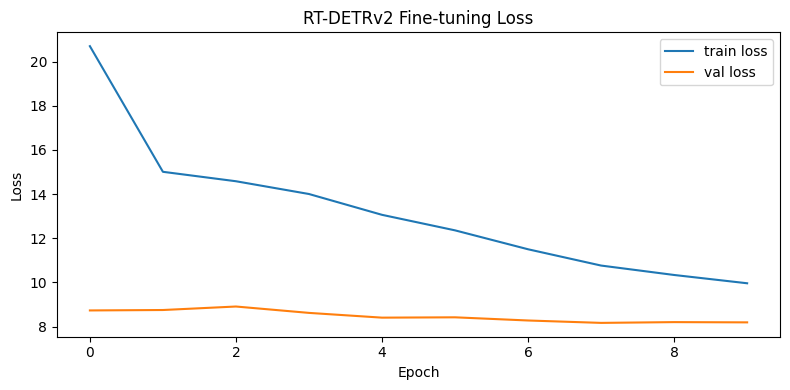

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import RTDetrV2ForObjectDetection, AutoImageProcessor
from PIL import Image
import numpy as np
from pathlib import Path

# ── Dataset ──────────────────────────────────────────────────────────────────
class ObjectDetectionDataset(Dataset):
    def __init__(self, image_paths, gt_df, processor, augment=False):
        self.processor = processor
        self.augment = augment
        self.samples = []

        name2path = {p.name: p for p in image_paths}
        for fname, group in gt_df.groupby("file_name"):
            if fname not in name2path:
                continue
            boxes = group[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].dropna().values.tolist()
            labels = group["category_id"].values.tolist()
            if boxes:
                self.samples.append((name2path[fname], boxes, labels))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, boxes, labels = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        W, H = image.size

        # Convert xywh pixel → normalized cxcywh (required by RT-DETRv2)
        cxcywh = []
        valid_labels = []
        for (x, y, w, h), lbl in zip(boxes, labels):
            x1, y1 = max(0.0, x), max(0.0, y)
            x2, y2 = min(W, x + w), min(H, y + h)
            if x2 > x1 and y2 > y1:
                cx = (x1 + x2) / 2 / W
                cy = (y1 + y2) / 2 / H
                bw = (x2 - x1) / W
                bh = (y2 - y1) / H
                cxcywh.append([cx, cy, bw, bh])
                valid_labels.append(lbl)

        target = {
            "boxes":  torch.tensor(cxcywh,       dtype=torch.float32),
            "labels": torch.tensor(valid_labels, dtype=torch.long),
            "image_id": torch.tensor([idx]),
        }
        return image, target


def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


# ── Hyperparameters ───────────────────────────────────────────────────────────
NUM_EPOCHS    = 10
BATCH_SIZE    = 4
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
SCORE_THR     = 0.35
GRAD_CLIP     = 0.1
SAVE_DIR      = Path("rtdetrv2_finetuned")
SAVE_DIR.mkdir(exist_ok=True)

# ── Build dataset & loader ────────────────────────────────────────────────────
full_dataset = ObjectDetectionDataset(image_paths, gt_df, processor)
n_val  = max(1, int(0.1 * len(full_dataset)))
n_train = len(full_dataset) - n_val
train_ds, val_ds = torch.utils.data.random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

# ── Model ─────────────────────────────────────────────────────────────────────
ft_model = RTDetrV2ForObjectDetection.from_pretrained(model_id).to(device).train()

optimizer = AdamW(ft_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = OneCycleLR(optimizer, max_lr=LR,
                       steps_per_epoch=len(train_loader),
                       epochs=NUM_EPOCHS)

# ── Training loop ─────────────────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, NUM_EPOCHS + 1):

    # — train —
    ft_model.train()
    running_loss = 0.0
    for images, targets in train_loader:
        encoding = processor(images=images, return_tensors="pt").to(device)

        labels_batch = []
        for t in targets:
            labels_batch.append({
                "class_labels": t["labels"].to(device),
                "boxes":        t["boxes"].to(device),   # normalized cxcywh
            })

        outputs = ft_model(**encoding, labels=labels_batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    avg_train = running_loss / len(train_loader)
    history["train_loss"].append(avg_train)

    # — validation —
    ft_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            encoding = processor(images=images, return_tensors="pt").to(device)
            labels_batch = [
                {"class_labels": t["labels"].to(device),
                 "boxes":        t["boxes"].to(device)}
                for t in targets
            ]
            val_loss += ft_model(**encoding, labels=labels_batch).loss.item()

    avg_val = val_loss / len(val_loader)
    history["val_loss"].append(avg_val)

    print(f"Epoch {epoch:>3}/{NUM_EPOCHS}  "
          f"train_loss={avg_train:.4f}  val_loss={avg_val:.4f}")

# ── Save ──────────────────────────────────────────────────────────────────────
ft_model.save_pretrained(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)
print(f"\nFine-tuned model saved to: {SAVE_DIR}")

# ── Loss curve ────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"],   label="val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("RT-DETRv2 Fine-tuning Loss")
plt.legend(); plt.tight_layout(); plt.show()



Evaluated 1026 images  |  IoU threshold = 0.5



,Metric,Baseline,Fine-tuned,Delta
0,Precision,0.5002,0.9686,0.4684
1,Recall,0.7692,0.5969,-0.1723
2,F1,0.6062,0.7386,0.1324
3,Mean IoU (TPs),0.8304,0.9070,0.0766


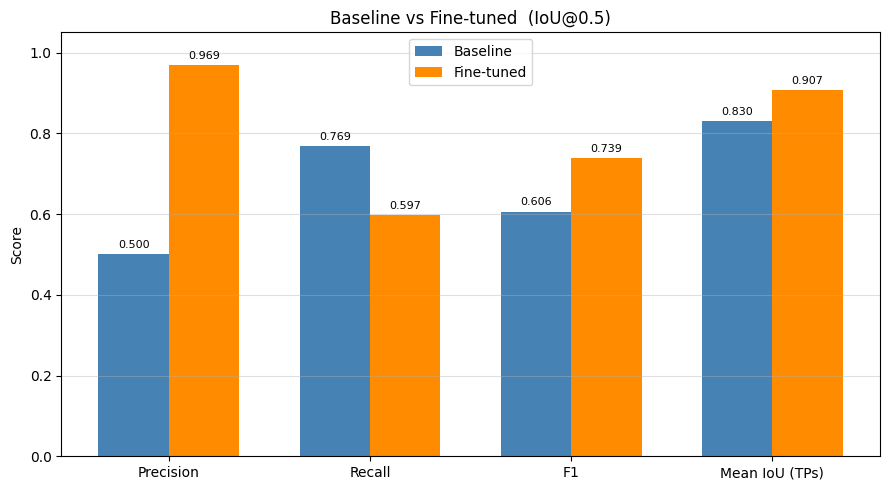

,file_name,gt_count,pred_count,tp,fp,fn,precision,recall
0,dusttornado-001.jpg,16,8,8,0,8,1.0,0.500000
1,dusttornado-002.jpg,10,8,8,0,2,1.0,0.800000
2,dusttornado-003.jpg,23,8,8,0,15,1.0,0.347826
3,dusttornado-004.jpg,7,5,5,0,2,1.0,0.714286
4,dusttornado-005.jpg,21,7,7,0,14,1.0,0.333333
5,dusttornado-006.jpg,3,2,2,0,1,1.0,0.666667
6,dusttornado-007.jpg,3,1,1,0,2,1.0,0.333333
7,dusttornado-008.jpg,45,16,16,0,29,1.0,0.355556
8,dusttornado-010.jpg,1,1,1,0,0,1.0,1.000000
9,dusttornado-012.jpg,13,8,8,0,5,1.0,0.615385


In [7]:
# Evaluate fine-tuned model performance (class-agnostic, IoU@0.50)

ft_model.eval()

ft_per_image_rows = []
ft_total_tp = ft_total_fp = ft_total_fn = 0
ft_all_matched_ious = []

for fname in eval_files:
    img_path = image_path_by_name[fname]

    gt_sub = gt_df.loc[gt_df["file_name"] == fname, ["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].dropna()
    if gt_sub.empty:
        gt_boxes = torch.zeros((0, 4), dtype=torch.float32)
    else:
        x1 = torch.tensor(gt_sub["bbox_x"].values, dtype=torch.float32)
        y1 = torch.tensor(gt_sub["bbox_y"].values, dtype=torch.float32)
        w_ = torch.tensor(gt_sub["bbox_w"].values, dtype=torch.float32)
        h_ = torch.tensor(gt_sub["bbox_h"].values, dtype=torch.float32)
        valid = (w_ > 0) & (h_ > 0)
        gt_boxes = torch.stack([x1[valid], y1[valid], x1[valid] + w_[valid], y1[valid] + h_[valid]], dim=1)

    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        out = ft_model(**inputs)

    ts = torch.tensor([image.size[::-1]], device=device)
    res = processor.post_process_object_detection(out, threshold=score_threshold, target_sizes=ts)[0]

    pred_boxes  = res["boxes"].detach().cpu()
    pred_scores = res["scores"].detach().cpu()

    tp, fp, fn, matched_ious = greedy_match(pred_boxes, pred_scores, gt_boxes, iou_thr=iou_threshold)

    ft_total_tp += tp
    ft_total_fp += fp
    ft_total_fn += fn
    ft_all_matched_ious.extend(matched_ious)

    ft_per_image_rows.append({
        "file_name": fname,
        "gt_count":  int(gt_boxes.shape[0]),
        "pred_count": int(pred_boxes.shape[0]),
        "tp": tp, "fp": fp, "fn": fn,
        "precision": tp / (tp + fp + 1e-9),
        "recall":    tp / (tp + fn + 1e-9),
    })

ft_precision      = ft_total_tp / (ft_total_tp + ft_total_fp + 1e-9)
ft_recall         = ft_total_tp / (ft_total_tp + ft_total_fn + 1e-9)
ft_f1             = 2 * ft_precision * ft_recall / (ft_precision + ft_recall + 1e-9)
ft_mean_iou       = sum(ft_all_matched_ious) / (len(ft_all_matched_ious) + 1e-9)

# ── comparison table ──────────────────────────────────────────────────────────
metrics = pd.DataFrame({
    "Metric":        ["Precision", "Recall", "F1", "Mean IoU (TPs)"],
    "Baseline":      [precision,    recall,    2*precision*recall/(precision+recall+1e-9), sum(all_matched_ious)/(len(all_matched_ious)+1e-9)],
    "Fine-tuned":    [ft_precision, ft_recall, ft_f1, ft_mean_iou],
})
metrics["Delta"] = metrics["Fine-tuned"] - metrics["Baseline"]
print(f"\nEvaluated {len(eval_files)} images  |  IoU threshold = {iou_threshold}\n")
display(metrics.round(4))

# ── bar chart ─────────────────────────────────────────────────────────────────
x = range(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], metrics["Baseline"],   width, label="Baseline",   color="steelblue")
bars2 = ax.bar([i + width/2 for i in x], metrics["Fine-tuned"], width, label="Fine-tuned", color="darkorange")
ax.set_xticks(list(x)); ax.set_xticklabels(metrics["Metric"])
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title(f"Baseline vs Fine-tuned  (IoU@{iou_threshold})")
ax.legend(); ax.grid(axis="y", alpha=0.4)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

ft_eval_df = pd.DataFrame(ft_per_image_rows).sort_values("file_name").reset_index(drop=True)
display(ft_eval_df.head(10))

,weather,images,gt_count,pred_count,TP,FP,FN,Precision,Recall,F1
0,mist,82,756,1016,581,435,175,0.5719,0.7685,0.6558
1,snow_storm,204,2072,3175,1628,1547,444,0.5128,0.7857,0.6205
2,foggy,104,572,928,459,469,113,0.4946,0.8024,0.6120
3,rain_storm,200,1588,2594,1268,1326,320,0.4888,0.7985,0.6064
4,sand_storm_g,55,436,634,324,310,112,0.5110,0.7431,0.6056
5,haze,113,623,1028,491,537,132,0.4776,0.7881,0.5948
6,sand_storm,232,1455,2227,1073,1154,382,0.4818,0.7375,0.5828
7,dusttornado,36,344,463,211,252,133,0.4557,0.6134,0.5229


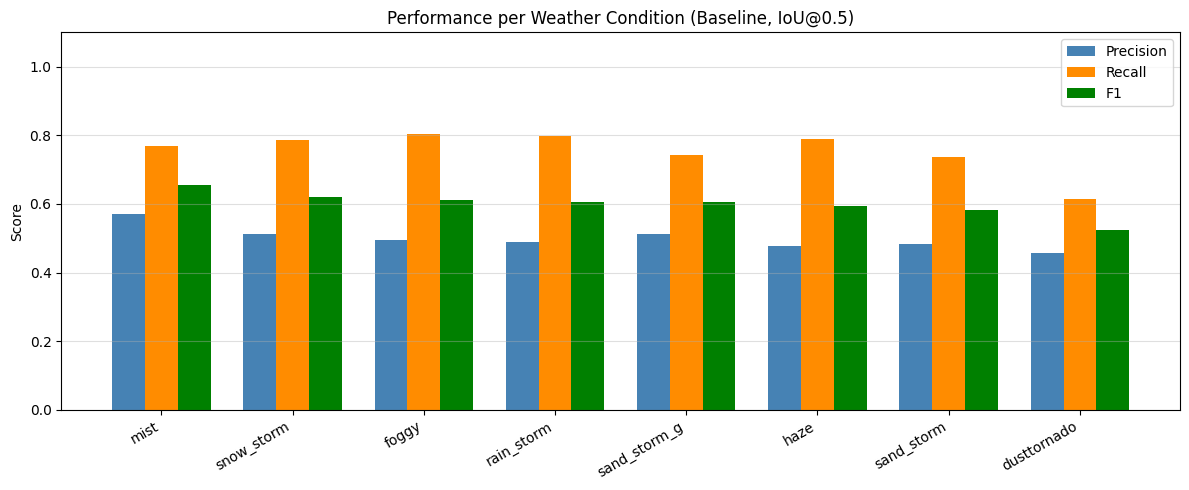

In [9]:
import re

# Extract weather condition from filename prefix
def get_weather(fname):
    # Remove trailing digits and extension, keep the word prefix
    match = re.match(r'^([a-zA-Z_]+)', fname)
    if match:
        return match.group(1).rstrip('-_')
    return 'unknown'

# Add weather condition column to eval_df
eval_df["weather"] = eval_df["file_name"].apply(get_weather)

# Aggregate per weather condition
weather_metrics = []
for weather, grp in eval_df.groupby("weather"):
    tp_sum = grp["tp"].sum()
    fp_sum = grp["fp"].sum()
    fn_sum = grp["fn"].sum()
    prec   = tp_sum / (tp_sum + fp_sum + 1e-9)
    rec    = tp_sum / (tp_sum + fn_sum + 1e-9)
    f1     = 2 * prec * rec / (prec + rec + 1e-9)
    weather_metrics.append({
        "weather":    weather,
        "images":     len(grp),
        "gt_count":   grp["gt_count"].sum(),
        "pred_count": grp["pred_count"].sum(),
        "TP":         tp_sum,
        "FP":         fp_sum,
        "FN":         fn_sum,
        "Precision":  round(prec, 4),
        "Recall":     round(rec,  4),
        "F1":         round(f1,   4),
    })

weather_df = pd.DataFrame(weather_metrics).sort_values("F1", ascending=False).reset_index(drop=True)
display(weather_df)

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = range(len(weather_df))
width = 0.25
ax.bar([i - width for i in x_pos], weather_df["Precision"], width, label="Precision", color="steelblue")
ax.bar([i          for i in x_pos], weather_df["Recall"],   width, label="Recall",    color="darkorange")
ax.bar([i + width  for i in x_pos], weather_df["F1"],       width, label="F1",        color="green")

ax.set_xticks(list(x_pos))
ax.set_xticklabels(weather_df["weather"], rotation=30, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title(f"Performance per Weather Condition (Baseline, IoU@{iou_threshold})")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()